In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Pragati\Desktop\E-Commerce Orders.csv')
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Month_Name'] = pd.to_datetime(df['Date']).dt.strftime('%b')
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

print(f'Total Records: {df.shape[0]}')
print(f'Total Columns: {df.shape[1]}')
df.head()

Total Records: 1200
Total Columns: 16


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Month_Name
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,Jan
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,Aug
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,Feb
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,Oct
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,May


In [3]:
total_revenue   = df['TotalPrice'].sum()
total_orders    = df['OrderID'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = df['TotalPrice'].mean()
return_rate     = (df['OrderStatus'] == 'Returned').sum() / len(df) * 100

print('==========================================')
print('      KEY BUSINESS PERFORMANCE METRICS    ')
print('==========================================')
print(f'  Total Revenue     : Rs. {total_revenue:,.2f}')
print(f'  Total Orders      : {total_orders}')
print(f'  Total Customers   : {total_customers}')
print(f'  Avg Order Value   : Rs. {avg_order_value:,.2f}')
print(f'  Return Rate       : {return_rate:.2f}%')
print('==========================================')

      KEY BUSINESS PERFORMANCE METRICS    
  Total Revenue     : Rs. 1,264,761.96
  Total Orders      : 1200
  Total Customers   : 1189
  Avg Order Value   : Rs. 1,053.97
  Return Rate       : 20.58%


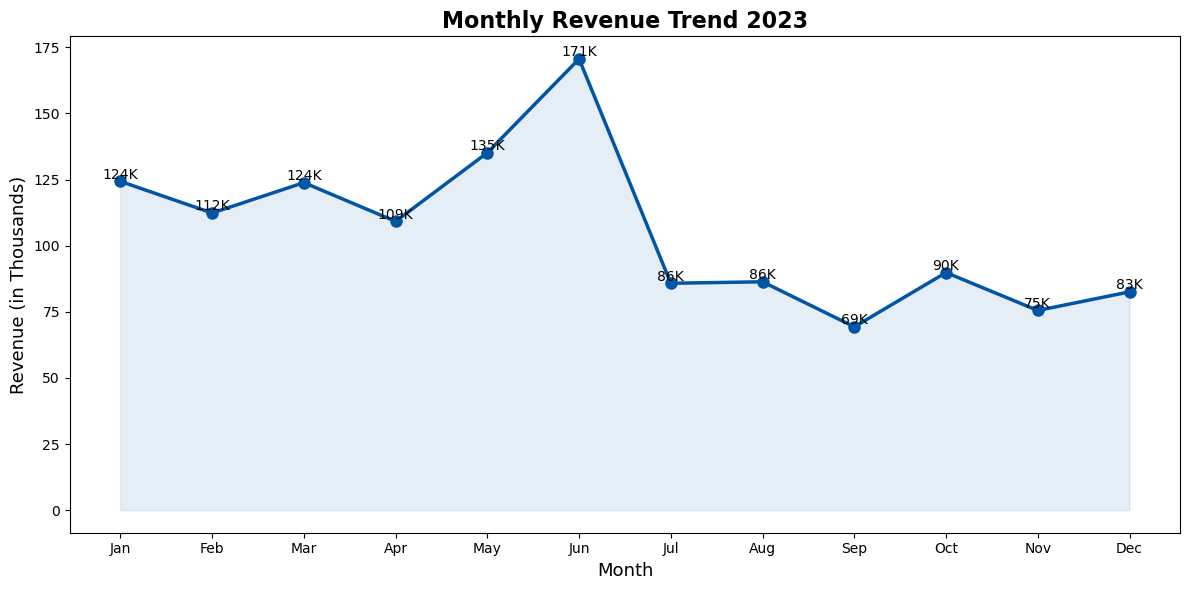

Chart 1 Done!


In [4]:
monthly = df.groupby(['Month', 'Month_Name'])['TotalPrice'].sum().reset_index()
monthly = monthly.sort_values('Month')

plt.figure(figsize=(12, 6))
plt.plot(monthly['Month_Name'], monthly['TotalPrice'] / 1000,
         marker='o', linewidth=2.5, color='#0055A5', markersize=8)
plt.fill_between(monthly['Month_Name'], 
                 monthly['TotalPrice'] / 1000,
                 alpha=0.1, color='#0055A5')

for i, row in monthly.iterrows():
    plt.text(row['Month_Name'], 
             row['TotalPrice'] / 1000 + 1,
             f"{row['TotalPrice']/1000:.0f}K", 
             ha='center', fontsize=10)

plt.title('Monthly Revenue Trend 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=13)
plt.ylabel('Revenue (in Thousands)', fontsize=13)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150)
plt.show()
print('Chart 1 Done!')

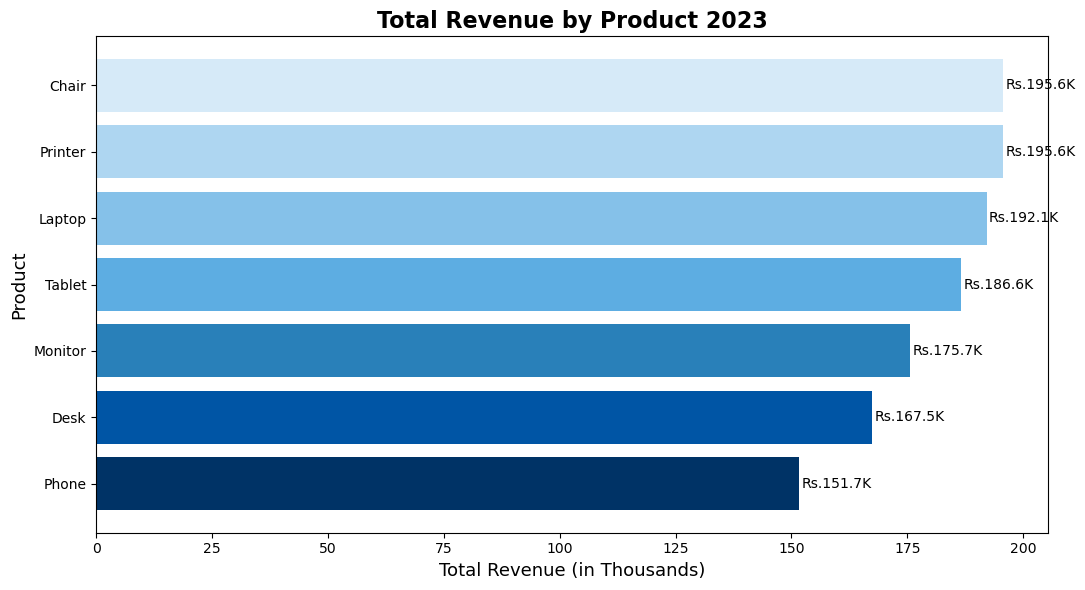

Chart 2 Done!


In [5]:
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=True)

colors = ['#003366','#0055A5','#2980B9',
          '#5DADE2','#85C1E9','#AED6F1','#D6EAF8']

plt.figure(figsize=(11, 6))
bars = plt.barh(product_rev.index, 
                product_rev.values / 1000, color=colors)

for bar, val in zip(bars, product_rev.values):
    plt.text(bar.get_width() + 0.5, 
             bar.get_y() + bar.get_height() / 2,
             f'Rs.{val/1000:.1f}K', 
             va='center', fontsize=10)

plt.title('Total Revenue by Product 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (in Thousands)', fontsize=13)
plt.ylabel('Product', fontsize=13)
plt.tight_layout()
plt.savefig('chart2_revenue_by_product.png', dpi=150)
plt.show()
print('Chart 2 Done!')

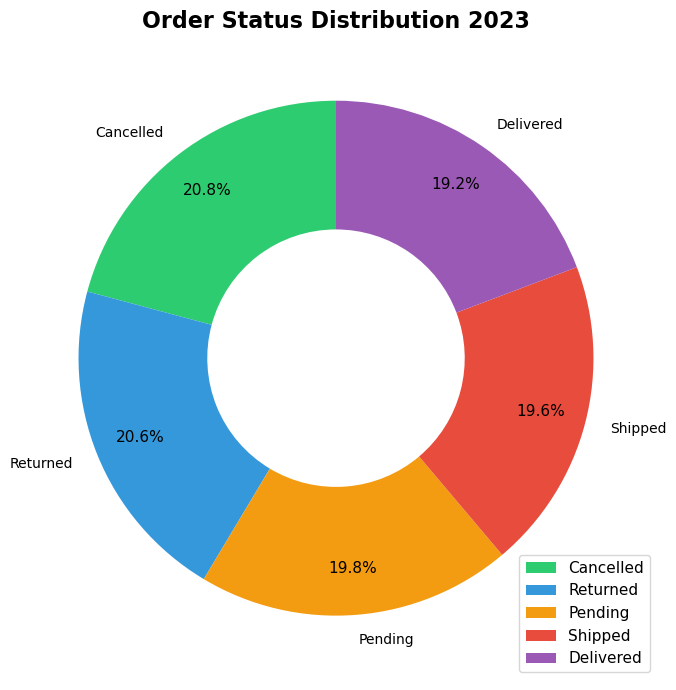

Chart 3 Done!


In [6]:
status_counts = df['OrderStatus'].value_counts()
colors_pie = ['#2ECC71','#3498DB','#F39C12','#E74C3C','#9B59B6']

plt.figure(figsize=(9, 7))
wedges, texts, autotexts = plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5)
)
for text in autotexts:
    text.set_fontsize(11)

plt.title('Order Status Distribution 2023', 
          fontsize=16, fontweight='bold')
plt.legend(status_counts.index, 
           loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('chart3_order_status.png', dpi=150)
plt.show()
print('Chart 3 Done!')

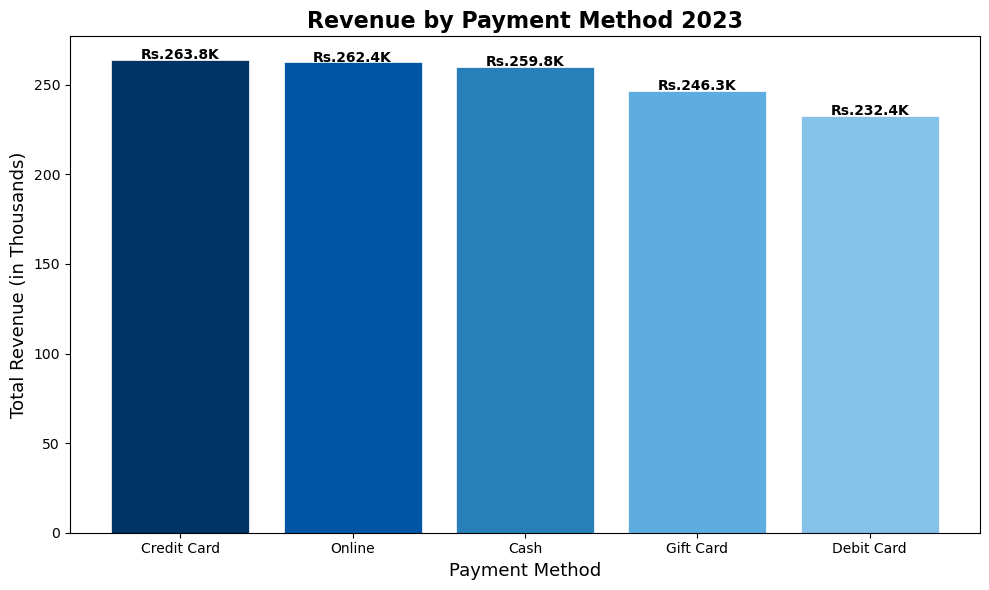

Chart 4 Done!


In [7]:
payment_rev = df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(payment_rev.index, 
               payment_rev.values / 1000,
               color=['#003366','#0055A5','#2980B9',
                      '#5DADE2','#85C1E9'],
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, payment_rev.values):
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height() + 0.5,
             f'Rs.{val/1000:.1f}K', 
             ha='center', fontsize=10, 
             fontweight='bold')

plt.title('Revenue by Payment Method 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Payment Method', fontsize=13)
plt.ylabel('Total Revenue (in Thousands)', fontsize=13)
plt.tight_layout()
plt.savefig('chart4_payment_method.png', dpi=150)
plt.show()
print('Chart 4 Done!')

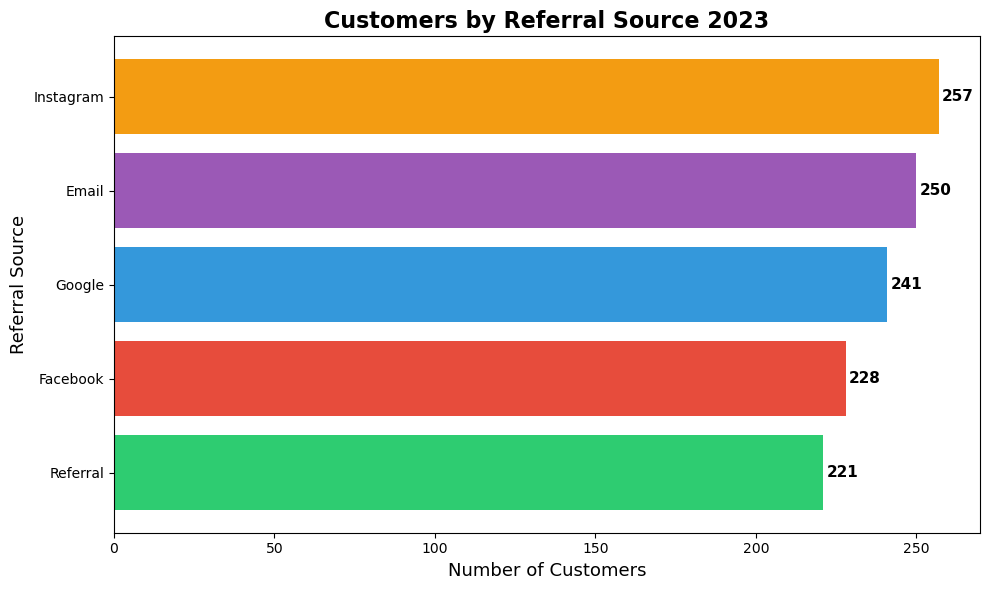

Chart 5 Done!


In [8]:
referral = df.groupby('ReferralSource')['CustomerID'].nunique().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(referral.index, referral.values,
                color=['#2ECC71','#E74C3C','#3498DB',
                       '#9B59B6','#F39C12'])

for bar, val in zip(bars, referral.values):
    plt.text(bar.get_width() + 1, 
             bar.get_y() + bar.get_height() / 2,
             str(val), va='center', 
             fontsize=11, fontweight='bold')

plt.title('Customers by Referral Source 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=13)
plt.ylabel('Referral Source', fontsize=13)
plt.tight_layout()
plt.savefig('chart5_referral_source.png', dpi=150)
plt.show()
print('Chart 5 Done!')

C:\Temp\ipykernel_19552\317647852.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return_rate_product = df.groupby('Product').apply(


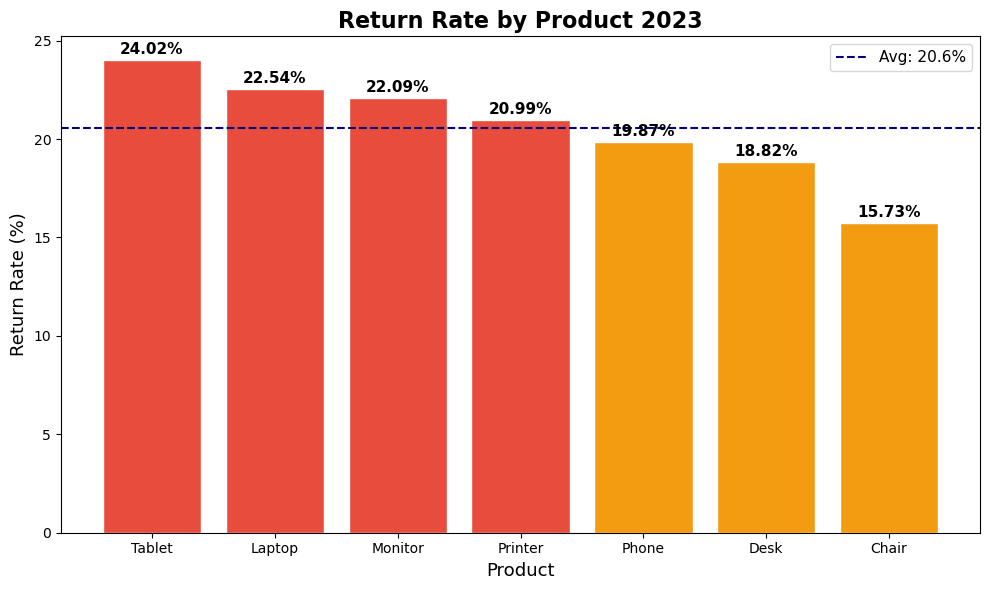

Chart 6 Done!


In [9]:
return_rate_product = df.groupby('Product').apply(
    lambda x: (x['OrderStatus'] == 'Returned').sum() / len(x) * 100
).sort_values(ascending=False).round(2)

plt.figure(figsize=(10, 6))
bars = plt.bar(return_rate_product.index, 
               return_rate_product.values,
               color=['#E74C3C' if v > 20 else '#F39C12' 
                      if v > 15 else '#2ECC71'
                      for v in return_rate_product.values],
               edgecolor='white')

for bar, val in zip(bars, return_rate_product.values):
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height() + 0.3,
             f'{val}%', ha='center', 
             fontsize=11, fontweight='bold')

plt.axhline(y=return_rate_product.mean(), 
            color='navy', linestyle='--', linewidth=1.5,
            label=f'Avg: {return_rate_product.mean():.1f}%')
plt.legend(fontsize=11)
plt.title('Return Rate by Product 2023', 
          fontsize=16, fontweight='bold')
plt.xlabel('Product', fontsize=13)
plt.ylabel('Return Rate (%)', fontsize=13)
plt.tight_layout()
plt.savefig('chart6_return_rate.png', dpi=150)
plt.show()
print('Chart 6 Done!')

In [10]:
best_product   = df.groupby('Product')['TotalPrice'].sum().idxmax()
best_payment   = df.groupby('PaymentMethod')['TotalPrice'].sum().idxmax()
best_referral  = df.groupby('ReferralSource')['CustomerID'].nunique().idxmax()
best_coupon    = df.groupby('CouponCode')['TotalPrice'].sum().idxmax()
most_cancelled = df[df['OrderStatus'] == 'Cancelled']['Product'].value_counts().idxmax()
overall_return = (df['OrderStatus'] == 'Returned').sum() / len(df) * 100

print('================================================')
print('        KEY FINDINGS FROM DATA ANALYSIS         ')
print('================================================')
print(f'  Highest Revenue Product  : {best_product}')
print(f'  Most Used Payment Method : {best_payment}')
print(f'  Top Referral Source      : {best_referral}')
print(f'  Best Performing Coupon   : {best_coupon}')
print(f'  Most Cancelled Product   : {most_cancelled}')
print(f'  Overall Return Rate      : {overall_return:.2f}%')
print('================================================')

        KEY FINDINGS FROM DATA ANALYSIS         
  Highest Revenue Product  : Chair
  Most Used Payment Method : Credit Card
  Top Referral Source      : Instagram
  Best Performing Coupon   : FREESHIP
  Most Cancelled Product   : Chair
  Overall Return Rate      : 20.58%
